# Analyse mit SHAP
SHAP soll das Modell transparent machen, indem es zeigt warum das Modell zu einem Ergebnis gekommen ist.

Es zeigt, welche Bereiche des Bildes zu einer bestimmten Entscheidung beigetragen haben (Theorie dahinter: Shapley values: Welche Elemente haben wie Stark beigetragen (Spieltheorie))

SHAP ist Modell-Angostisch


### Import der Bibs und Module

In [ ]:
import sys
import numpy as np
import shap
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
import os

# Findet den absoluten Pfad zur Projektwurzel (eine Ebene über dem 'notebooks' Ordner)
# Holt den Pfad zum Ordner, in dem das Notebook liegt (z.B. notebooks/)
NOTEBOOK_DIR = Path.cwd() 
# Fügt den Elternordner (Computer-Vision_Soccer/) zum Suchpfad hinzu
PROJECT_ROOT = NOTEBOOK_DIR.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
# -----------------------------------

# Projekt-Module
from src.config import *
from src.models.modelManager import ModelManager
from src.visualization.visualize import visualize_detections, show_grid

# Initiale Konfiguration für SHAP Plots
shap.initjs()

print("Imports erfolgreich und SHAP initialisiert.")

### Laden von Modell und Daten
Für die vergleichbarkeit nutze ich erstmal dieselben wie bei LIME

In [ ]:
# 1. Modell laden
model_manager = ModelManager()
model_manager.load_model()

# 2. Bilder Pfade laden
total_images = sorted(list(DATASET_PATH.rglob("*.jpg")))
print(f"Anzahl Bilder im Dataset: {len(total_images)}")

# 3. Nutzung derselben Bilder wie in der LIME Analyse für Vergleichbarkeit
IMAGES_INDICES = [4298, 1390, 362, 3029, 4247, 726, 4257, 4859, 1288]

# Kleiner Helper um das Bild direkt als Numpy Array zu laden
def get_image_by_index(index):
    try:
        img_path = total_images[index]
        return Image.open(img_path)
    except IndexError:
        print(f"Index {index} nicht gefunden!")
        return None

print(f"Analysiere folgende Indizes: {IMAGES_INDICES}")

⬇ Lade Modell: football-ball-detection-rejhg/4
  (Verwendet Cache falls bereits heruntergeladen)


✓ Modell geladen
Anzahl Bilder im Dataset: 4948
Analysiere folgende Indizes: [4298, 1390, 362, 3029, 4247, 726, 4257, 4859, 1288]


### Wrapper Funktion
Bild wird als NUMPY Array maskiert.

In [ ]:
def detection_wrapper(numpy_images):
    """
    Wandelt SHAP's Numpy-Input in Input für den ModelManager um
    und gibt die Konfidenz für die Klasse 'ball' zurück.
    
    Args:
        numpy_images: Ein Batch von Bildern als Numpy Array (N, H, W, C)
    
    Returns:
        Ein Numpy Array mit den Scores (N,)
    """
    results = []
    
    for img_arr in numpy_images:
        # SHAP übergibt oft normalisierte Daten (0-1) oder uint8 (0-255)
        if img_arr.max() <= 1.0:
            img_arr = (img_arr * 255).astype(np.uint8)
        else:
            img_arr = img_arr.astype(np.uint8)
            
        # Konvertierung zu PIL für den ModelManager
        pil_img = Image.fromarray(img_arr)
        
        # Inference durchführen
        # Fehler abfangen, falls das Bild durch Maskierung "kaputt" ist
        try:
            inference_result = model_manager.infer(pil_img)
            
            # Suchen der höchste Confidence für einen Ball im Bild
            # Wenn kein Ball gefunden wurde, ist der Score 0.0
            max_confidence = 0.0
            
            if hasattr(inference_result, 'predictions'):
                for pred in inference_result.predictions:
                    if pred.confidence > max_confidence:
                        max_confidence = pred.confidence
            
            results.append(max_confidence)
            
        except Exception as e:
            # Fallback falls Inference fehlschlägt
            results.append(0.0)
            
    return np.array(results)

print("Wrapper-Funktion definiert.")

Wrapper-Funktion definiert.


### Analysefunktion

In [ ]:
def analyze_with_shap(image_index, max_evals=500):
    # 1. Bild laden
    original_img = get_image_by_index(image_index)
    if original_img is None: return

    # In Numpy wandeln
    img_numpy = np.array(original_img)
    
    print(f"\nStarte SHAP Analyse für Bild Index {image_index}...")
    print(f"Bildgröße: {img_numpy.shape}")
    
    # 2. Masker definieren
    # "inpaint_telea" füllt maskierte Bereiche intelligent auf (besser als Grau/Schwarz)
    # Das hilft, Artefakte zu vermeiden.
    masker = shap.maskers.Image("inpaint_telea", img_numpy.shape)

    # 3. Explainer erstellen
    # Übergabe der Wrapper-Funktion und den Masker
    explainer = shap.Explainer(detection_wrapper, masker)

    # 4. Shap Values berechnen
    # max_evals bestimmt, wie oft das Modell abgefragt wird. 
    # Höher = genauer, aber langsamer. 
    shap_values = explainer(
        img_numpy[np.newaxis, ...], # SHAP erwartet eine Batch-Dimension (1, H, W, C)
        max_evals=max_evals,
        batch_size=10 # Batch processing um API Calls zu sparen (falls möglich)
    )

    # 5. Visualisierung
    # Zeige zuerst das Original mit Detection
    print("Original Detection:")
    res = model_manager.infer(original_img)
    annotated = visualize_detections(original_img, res)
    plt.figure(figsize=(8, 6))
    plt.imshow(annotated)
    plt.axis('off')
    plt.title(f"Original Prediction (Index {image_index})")
    plt.show()

    print("SHAP Erklärung (Rot = Positiver Einfluss, Blau = Negativer Einfluss):")
    # shap.image_plot zeigt die Pixel-Wichtigkeit
    shap.image_plot(shap_values)

# Durchführung der Analyse

### Anzahl der Evaluierungen: Hyperparameteroptimierung
Erstmal möchte ich ein Gefühl für eine sinnvolle Anzahl der Durchläufe bekommen.'


Starte SHAP Analyse für Bild Index 4298...
Bildgröße: (640, 640, 3)


PartitionExplainer explainer: 2it [21:13, 1273.93s/it]             


Original Detection:


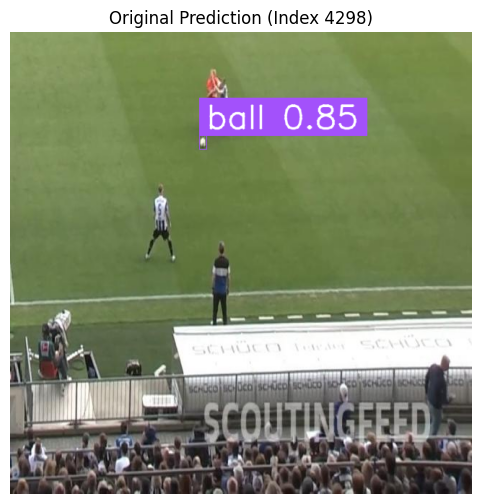

SHAP Erklärung (Rot = Positiver Einfluss, Blau = Negativer Einfluss):


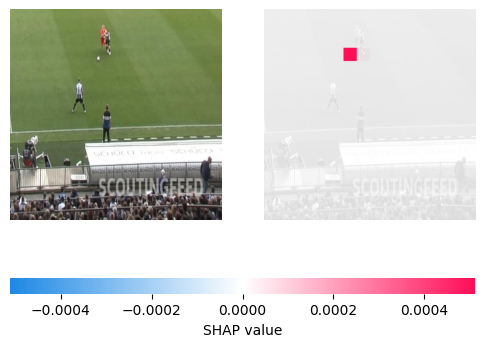

In [6]:
analyze_with_shap(IMAGES_INDICES[0], max_evals=500)


Starte SHAP Analyse für Bild Index 4298...
Bildgröße: (640, 640, 3)


PartitionExplainer explainer: 2it [31:11, 1871.74s/it]             


Original Detection:


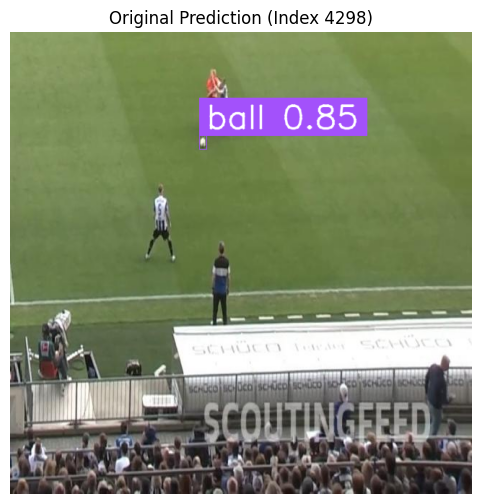

SHAP Erklärung (Rot = Positiver Einfluss, Blau = Negativer Einfluss):


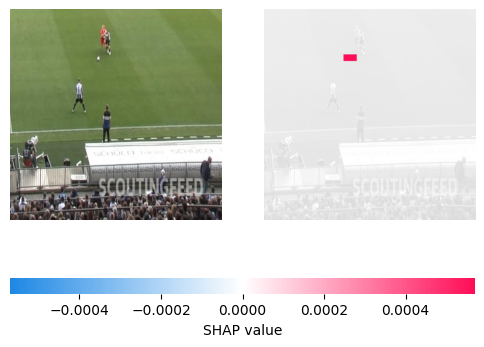

In [6]:
analyze_with_shap(IMAGES_INDICES[0], max_evals=1500)


Starte SHAP Analyse für Bild Index 4298...
Bildgröße: (640, 640, 3)


PartitionExplainer explainer: 2it [1:07:49, 4069.64s/it]           


Original Detection:


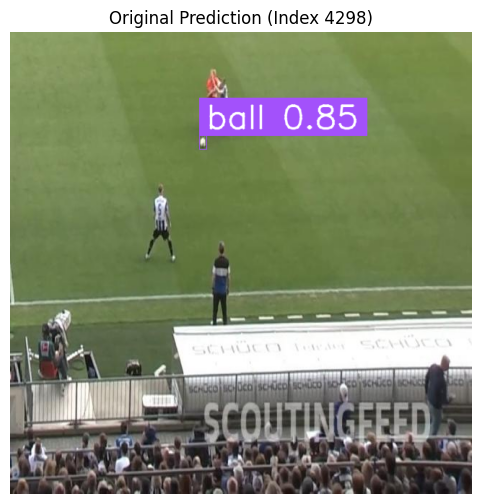

SHAP Erklärung (Rot = Positiver Einfluss, Blau = Negativer Einfluss):


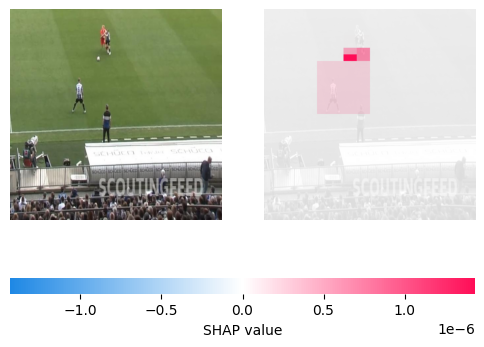

In [16]:
analyze_with_shap(IMAGES_INDICES[0], max_evals=3000)

Bestätigt die Theorie, dass der Kontext, insbesondere die Beine für die Klassifizierung wichtig sind.

Hier scheint deutlich mehr einbezogen. Es beschränkt sich auch nicht nur auf den einen Kernpunkt des Balles.
--> die weiteren Bilder werde ich mit 3000 Evaluationen betrachten.

### Analyse der weiteren Bilder


Starte SHAP Analyse für Bild Index 1390...
Bildgröße: (640, 640, 3)


PartitionExplainer explainer: 2it [1:00:54, 3654.79s/it]           


Original Detection:


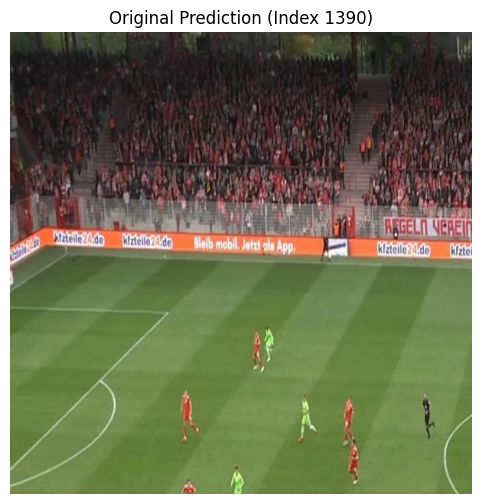

SHAP Erklärung (Rot = Positiver Einfluss, Blau = Negativer Einfluss):


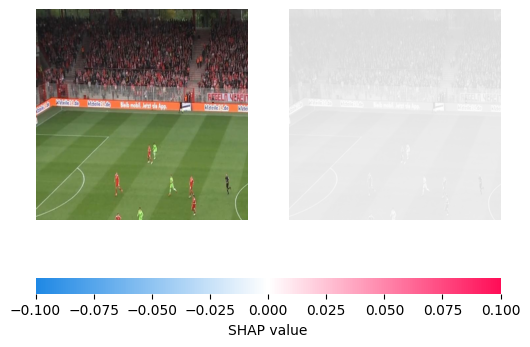

In [8]:
analyze_with_shap(IMAGES_INDICES[1], max_evals=3000)

Eigentlich zu erwarten, weil ja gar keine Klassifikation vom Modell erfolgt ist
--> eine generelle Problematik in meiner umgesetzten SHAP-Analyse


Starte SHAP Analyse für Bild Index 362...
Bildgröße: (640, 640, 3)


PartitionExplainer explainer: 2it [1:07:54, 4074.66s/it]           


Original Detection:


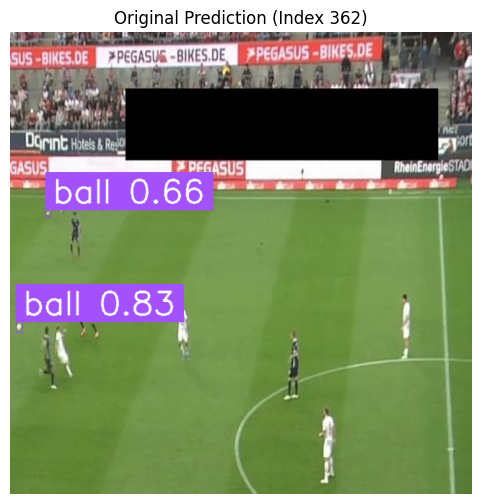

SHAP Erklärung (Rot = Positiver Einfluss, Blau = Negativer Einfluss):


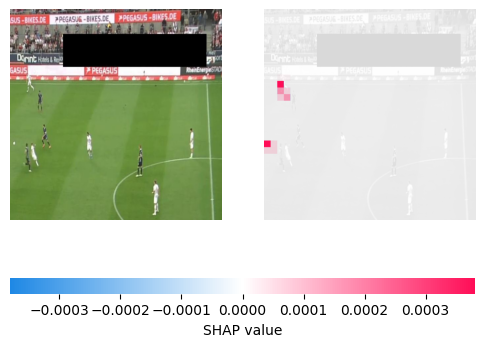

In [9]:
analyze_with_shap(IMAGES_INDICES[2], max_evals=3000)

Bestätigt die Theorie vom Kontext.


Starte SHAP Analyse für Bild Index 3029...
Bildgröße: (640, 640, 3)


PartitionExplainer explainer: 2it [10:28:32, 37712.36s/it]         


Original Detection:


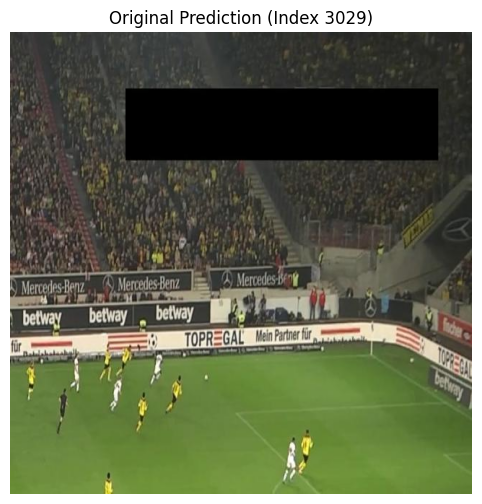

SHAP Erklärung (Rot = Positiver Einfluss, Blau = Negativer Einfluss):


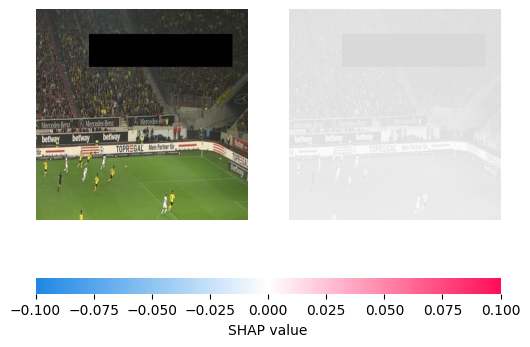

In [10]:
analyze_with_shap(IMAGES_INDICES[3], max_evals=3000)

Aus dieser Analyse sind keine wirklichen Erklärungen abzuleiten warum der Ball nicht erkannt wurde, außer, dass Möglicherweise das Modell einen falschen Fokus hat --> Analyse mit Grad-CAM


Starte SHAP Analyse für Bild Index 4247...
Bildgröße: (640, 640, 3)


PartitionExplainer explainer: 2it [1:03:12, 3792.74s/it]           


Original Detection:


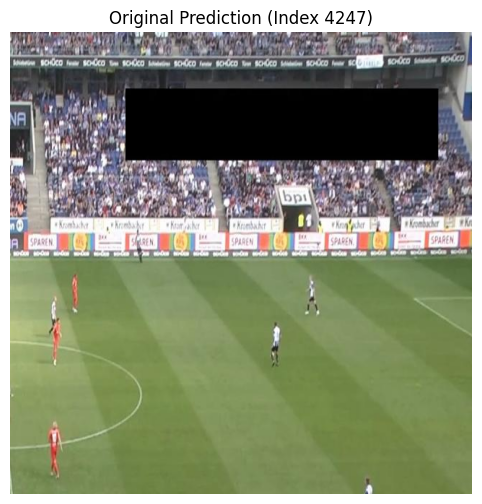

SHAP Erklärung (Rot = Positiver Einfluss, Blau = Negativer Einfluss):


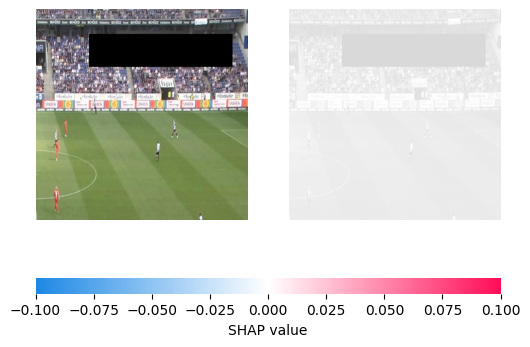

In [11]:
analyze_with_shap(IMAGES_INDICES[4], max_evals=3000)

Dasselbe wie beim Bild zuvor


Starte SHAP Analyse für Bild Index 726...
Bildgröße: (640, 640, 3)


PartitionExplainer explainer: 2it [1:06:59, 4019.87s/it]           


Original Detection:


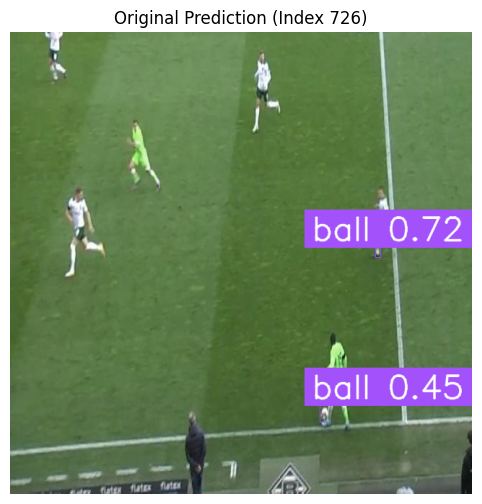

SHAP Erklärung (Rot = Positiver Einfluss, Blau = Negativer Einfluss):


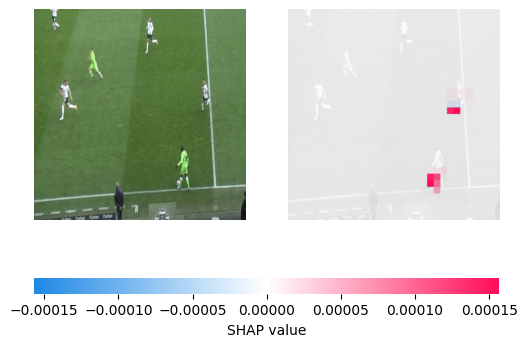

In [12]:
analyze_with_shap(IMAGES_INDICES[5], max_evals=3000)

Auch hier ist der Kontext Relevant. Interessant: das Bein spricht eher dagegen. Dennoch scheint der Fuß so ähnlich, dass er fehlerhaft Detected wird.


Starte SHAP Analyse für Bild Index 4257...
Bildgröße: (640, 640, 3)


PartitionExplainer explainer: 2it [1:02:20, 3740.67s/it]           


Original Detection:


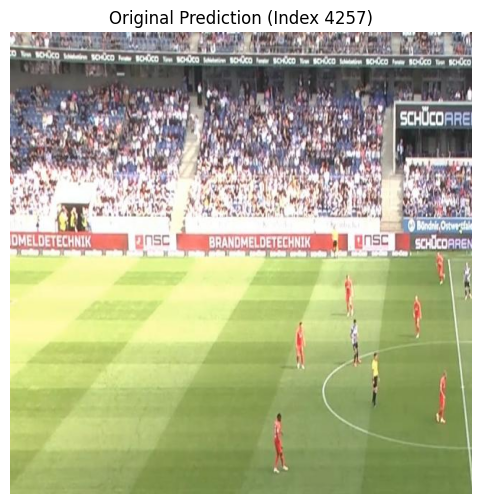

SHAP Erklärung (Rot = Positiver Einfluss, Blau = Negativer Einfluss):


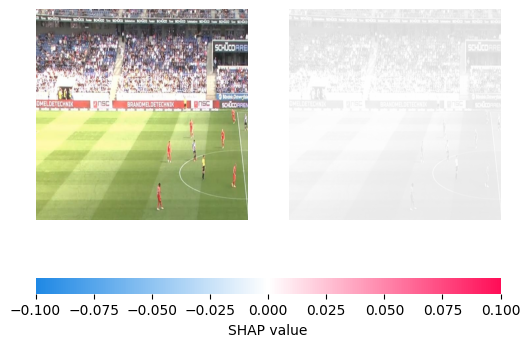

In [13]:
analyze_with_shap(IMAGES_INDICES[6], max_evals=3000)

Hier wird Korrekterweise nichts Detectet und es gibt in beide Richtungen auch keine Anhaltspunkte


Starte SHAP Analyse für Bild Index 4859...
Bildgröße: (640, 640, 3)


PartitionExplainer explainer: 2it [1:05:07, 3907.36s/it]           


Original Detection:


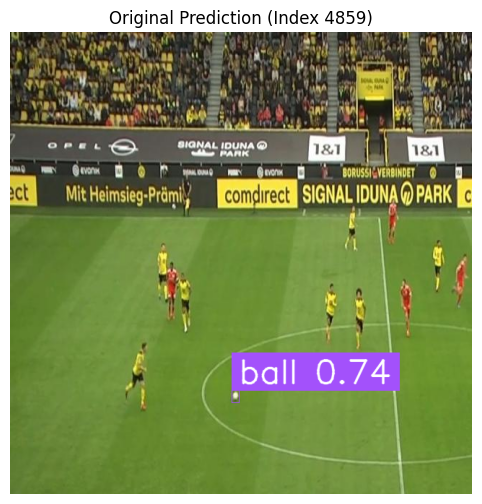

SHAP Erklärung (Rot = Positiver Einfluss, Blau = Negativer Einfluss):


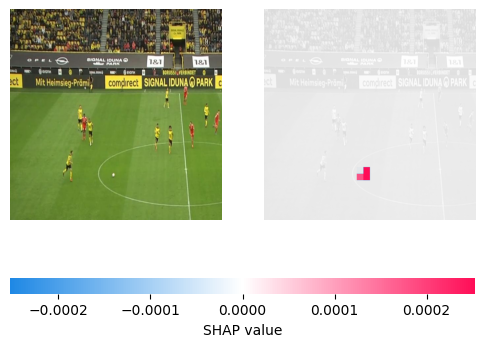

In [14]:
analyze_with_shap(IMAGES_INDICES[7], max_evals=3000)

Auch hier ist der Bereich der Einfluss hat relativ Präzise.


Starte SHAP Analyse für Bild Index 1288...
Bildgröße: (640, 640, 3)


PartitionExplainer explainer: 2it [1:08:08, 4088.53s/it]           


Original Detection:


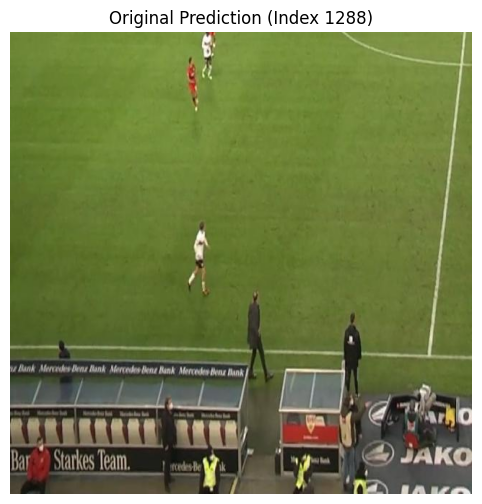

SHAP Erklärung (Rot = Positiver Einfluss, Blau = Negativer Einfluss):


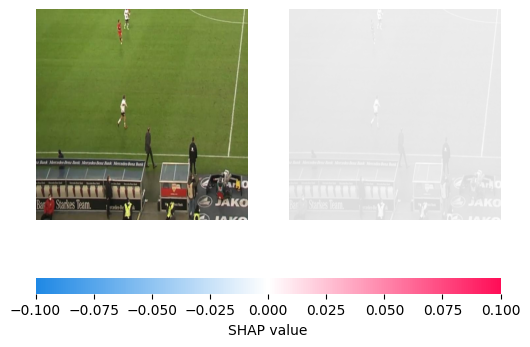

In [15]:
analyze_with_shap(IMAGES_INDICES[8], max_evals=3000)

TN: Keinerlei Relevanten Aspekte der SHAP-Analyse